In [23]:
pip install beautifulsoup4 --break-system-packages


Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [1]:
pip install requests --break-system-packages


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install lxml --break-system-packages


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [24]:
import requests
from bs4 import BeautifulSoup
import pandas as pd


In [25]:
# Step 1: Visit a website

url = 'http://quotes.toscrape.com/'
response = requests.get(url)

print(f' Status code: {response.status_code}')
print(f" Page length: {len(response.text)} characters")


 Status code: 200
 Page length: 11021 characters


In [26]:
# Step 2: Parse (understand) the HTML

soup= BeautifulSoup(response.text, 'lxml')

# Let's see what we got (first 500 characters)

print(soup.prettify()[:500])

<!DOCTYPE html>
<html lang="en">
 <head>
  <meta charset="utf-8"/>
  <title>
   Quotes to Scrape
  </title>
  <link href="/static/bootstrap.min.css" rel="stylesheet"/>
  <link href="/static/main.css" rel="stylesheet"/>
 </head>
 <body>
  <div class="container">
   <div class="row header-box">
    <div class="col-md-8">
     <h1>
      <a href="/" style="text-decoration: none">
       Quotes to Scrape
      </a>
     </h1>
    </div>
    <div class="col-md-4">
     <p>
      <a href="/login">
   


In [28]:
# Step 3: Find all quotes on the page

qoutes= soup.find_all('span', class_='text')
authors=soup.find_all('small', class_='author')

len(qoutes)

for i in range(len(qoutes)):
    print(f"\n {i+1} .{qoutes[i].text} - {authors[i].text}")



 1 .“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.” - Albert Einstein

 2 .“It is our choices, Harry, that show what we truly are, far more than our abilities.” - J.K. Rowling

 3 .“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.” - Albert Einstein

 4 .“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.” - Jane Austen

 5 .“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.” - Marilyn Monroe

 6 .“Try not to become a man of success. Rather become a man of value.” - Albert Einstein

 7 .“It is better to be hated for what you are than to be loved for what you are not.” - André Gide

 8 .“I have not failed. I've just found 10,000 ways that won't work.” - Thomas A. Edison

 9 .“A woman is like a tea bag; you never know how strong i

In [29]:
# Step 4: Create a structured dataset

qoute_data = []

for i in range(len(qoutes)):
    
    qoute_data.append({
        'qoute':qoutes[i].text,
        'author':authors[i].text
    })

df=pd.DataFrame(qoute_data)

df.to_csv('scrapped_qoutes.csv', index=False)
print("Scrapping of data successful and saved")

Scrapping of data successful and saved


In [30]:
# Scraping multiple pages

all_qoutes=[]

base_url = 'http://quotes.toscrape.com/page/{}/'

for page_num in range(1,11):
    print(f'Scraping page {page_num}...')

    #url for the page
    url = base_url.format(page_num)

    #visit the page
    response=requests.get(url)
    soup=BeautifulSoup(response.text, 'lxml')

    #find qoutes and author from Page
    quotes= soup.find_all('span', class_="text")
    authors= soup.find_all('small', class_="author")
    tags= soup.find_all('div', class_="tags")

    #extract data

    for i in range(len(qoutes)):
        qoute_tags= [tag.text for tag in tags[i].find_all('a', class_='tag')]

        all_qoutes.append({
            'qoute': qoutes[i].text,
            'author': authors[i].text,
            'tags': ', '.join(qoute_tags)  #convert list to string
        })

df=pd.DataFrame(all_qoutes)

print(f" df {df.head(10)}")

df.to_csv('all_qoutes.csv', index=False)
        

Scraping page 1...
Scraping page 2...
Scraping page 3...
Scraping page 4...
Scraping page 5...
Scraping page 6...
Scraping page 7...
Scraping page 8...
Scraping page 9...
Scraping page 10...
 df                                                qoute             author  \
0  “The world as we have created it is a process ...    Albert Einstein   
1  “It is our choices, Harry, that show what we t...       J.K. Rowling   
2  “There are only two ways to live your life. On...    Albert Einstein   
3  “The person, be it gentleman or lady, who has ...        Jane Austen   
4  “Imperfection is beauty, madness is genius and...     Marilyn Monroe   
5  “Try not to become a man of success. Rather be...    Albert Einstein   
6  “It is better to be hated for what you are tha...         André Gide   
7  “I have not failed. I've just found 10,000 way...   Thomas A. Edison   
8  “A woman is like a tea bag; you never know how...  Eleanor Roosevelt   
9  “A day without sunshine is like, you know, nig...   

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4764\1205997643.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=author_counts.values, y=author_counts.index, palette='rocket')


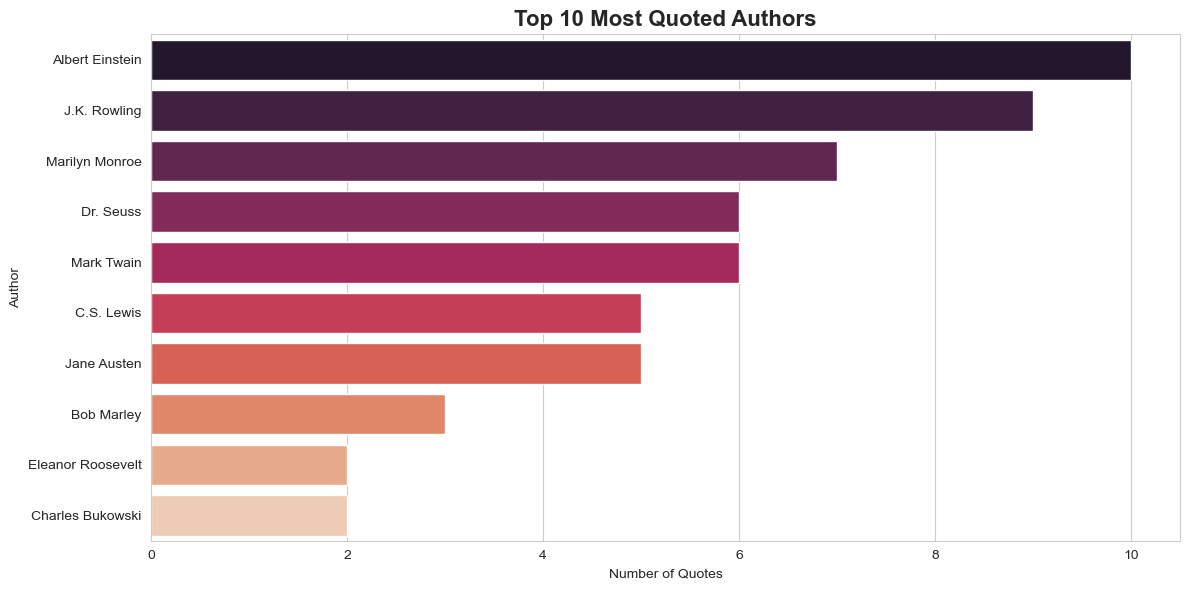

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Who has the most quotes?
author_counts = df['author'].value_counts().head(10) # .head(n) gives you top counts of authors 

plt.figure(figsize=(12, 6))
sns.barplot(x=author_counts.values, y=author_counts.index, palette='rocket')
plt.title('Top 10 Most Quoted Authors', fontsize=16, fontweight='bold')
plt.xlabel('Number of Quotes')
plt.ylabel('Author')
plt.tight_layout()
plt.show()

# Method 2: Using web scrapping

In [32]:
import requests
import json

# We'll use OpenWeatherMap API (free!)
# You need an API key (like a password)

# For this tutorial, I'll give you a demo key
# In real projects, you'd sign up at: https://openweathermap.org/api

api_key = '895284fb2d2c50a520ea537456963d9c'  # Demo key

In [33]:
# Get current weather for Mumbai

city = 'Mumbai'
url = f'http://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}&units=metric'

# Make API request
response = requests.get(url)

# Parse JSON response
weather_data = response.json()

print("🌤️ WEATHER DATA (RAW JSON):")
print(json.dumps(weather_data, indent=2))

🌤️ WEATHER DATA (RAW JSON):
{
  "coord": {
    "lon": 72.8479,
    "lat": 19.0144
  },
  "weather": [
    {
      "id": 721,
      "main": "Haze",
      "description": "haze",
      "icon": "50d"
    }
  ],
  "base": "stations",
  "main": {
    "temp": 32.99,
    "feels_like": 39.99,
    "temp_min": 32.94,
    "temp_max": 32.99,
    "pressure": 1006,
    "humidity": 62,
    "sea_level": 1006,
    "grnd_level": 1005
  },
  "visibility": 5000,
  "wind": {
    "speed": 5.14,
    "deg": 280
  },
  "clouds": {
    "all": 20
  },
  "dt": 1778742374,
  "sys": {
    "type": 1,
    "id": 9052,
    "country": "IN",
    "sunrise": 1778718883,
    "sunset": 1778765720
  },
  "timezone": 19800,
  "id": 1275339,
  "name": "Mumbai",
  "cod": 200
}


In [34]:
# Extract useful information

city_name = weather_data['name']
temperature = weather_data['main']['temp']
feels_like = weather_data['main']['feels_like']
humidity = weather_data['main']['humidity']
description = weather_data['weather'][0]['description']
wind_speed = weather_data['wind']['speed']

print("="*50)
print(f"🌍 WEATHER IN {city_name.upper()}")
print("="*50)
print(f"🌡️  Temperature: {temperature}°C")
print(f"🤔 Feels like: {feels_like}°C")
print(f"💧 Humidity: {humidity}%")
print(f"☁️  Description: {description.title()}")
print(f"💨 Wind speed: {wind_speed} m/s")
print("="*50)

🌍 WEATHER IN MUMBAI
🌡️  Temperature: 32.99°C
🤔 Feels like: 39.99°C
💧 Humidity: 62%
☁️  Description: Haze
💨 Wind speed: 5.14 m/s


In [35]:
# Get weather for multiple Indian cities

indian_cities = ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Kolkata', 
                 'Hyderabad', 'Pune', 'Ahmedabad', 'Jaipur', 'Lucknow']

weather_list=[]

for city in indian_cities:
    print(f"GaThering Data for {city}....")

    url = f'http://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}&units=metric'
    response= requests.get(url)
    data=response.json()

    weather_list.append({
        'city': data['name'],
        'temperature': data['main']['temp'],
        'feels_like': data['main']['feels_like'],
        'humidity': data['main']['humidity'],
        'description': data['weather'][0]['description'],
        'wind_speed': data['wind']['speed']
    })

df=pd.DataFrame(weather_list)
print(df)

df.to_csv('indian_weather.csv', index=False)



GaThering Data for Mumbai....
GaThering Data for Delhi....
GaThering Data for Bangalore....
GaThering Data for Chennai....
GaThering Data for Kolkata....
GaThering Data for Hyderabad....
GaThering Data for Pune....
GaThering Data for Ahmedabad....
GaThering Data for Jaipur....
GaThering Data for Lucknow....
        city  temperature  feels_like  humidity       description  wind_speed
0     Mumbai        32.99       39.99        62              haze        5.14
1      Delhi        37.05       36.51        25  scattered clouds        2.57
2  Bengaluru        32.30       33.52        44  scattered clouds       12.96
3    Chennai        33.70       40.70        69  scattered clouds        4.12
4    Kolkata        33.97       39.02        52              haze        0.00
5  Hyderabad        36.23       38.25        36              haze        3.09
6       Pune        35.78       33.36        15   overcast clouds        4.29
7  Ahmedabad        38.02       37.93        25             smoke  

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4764\3712493194.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='temperature', y='city', palette='Reds_r', ax=axes[0, 0])
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4764\3712493194.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='humidity', y='city', palette='Blues_r', ax=axes[0, 1])
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4764\3712493194.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='wind_speed', y='city', palette='Greens_r', ax=axes[1, 1])
C:\

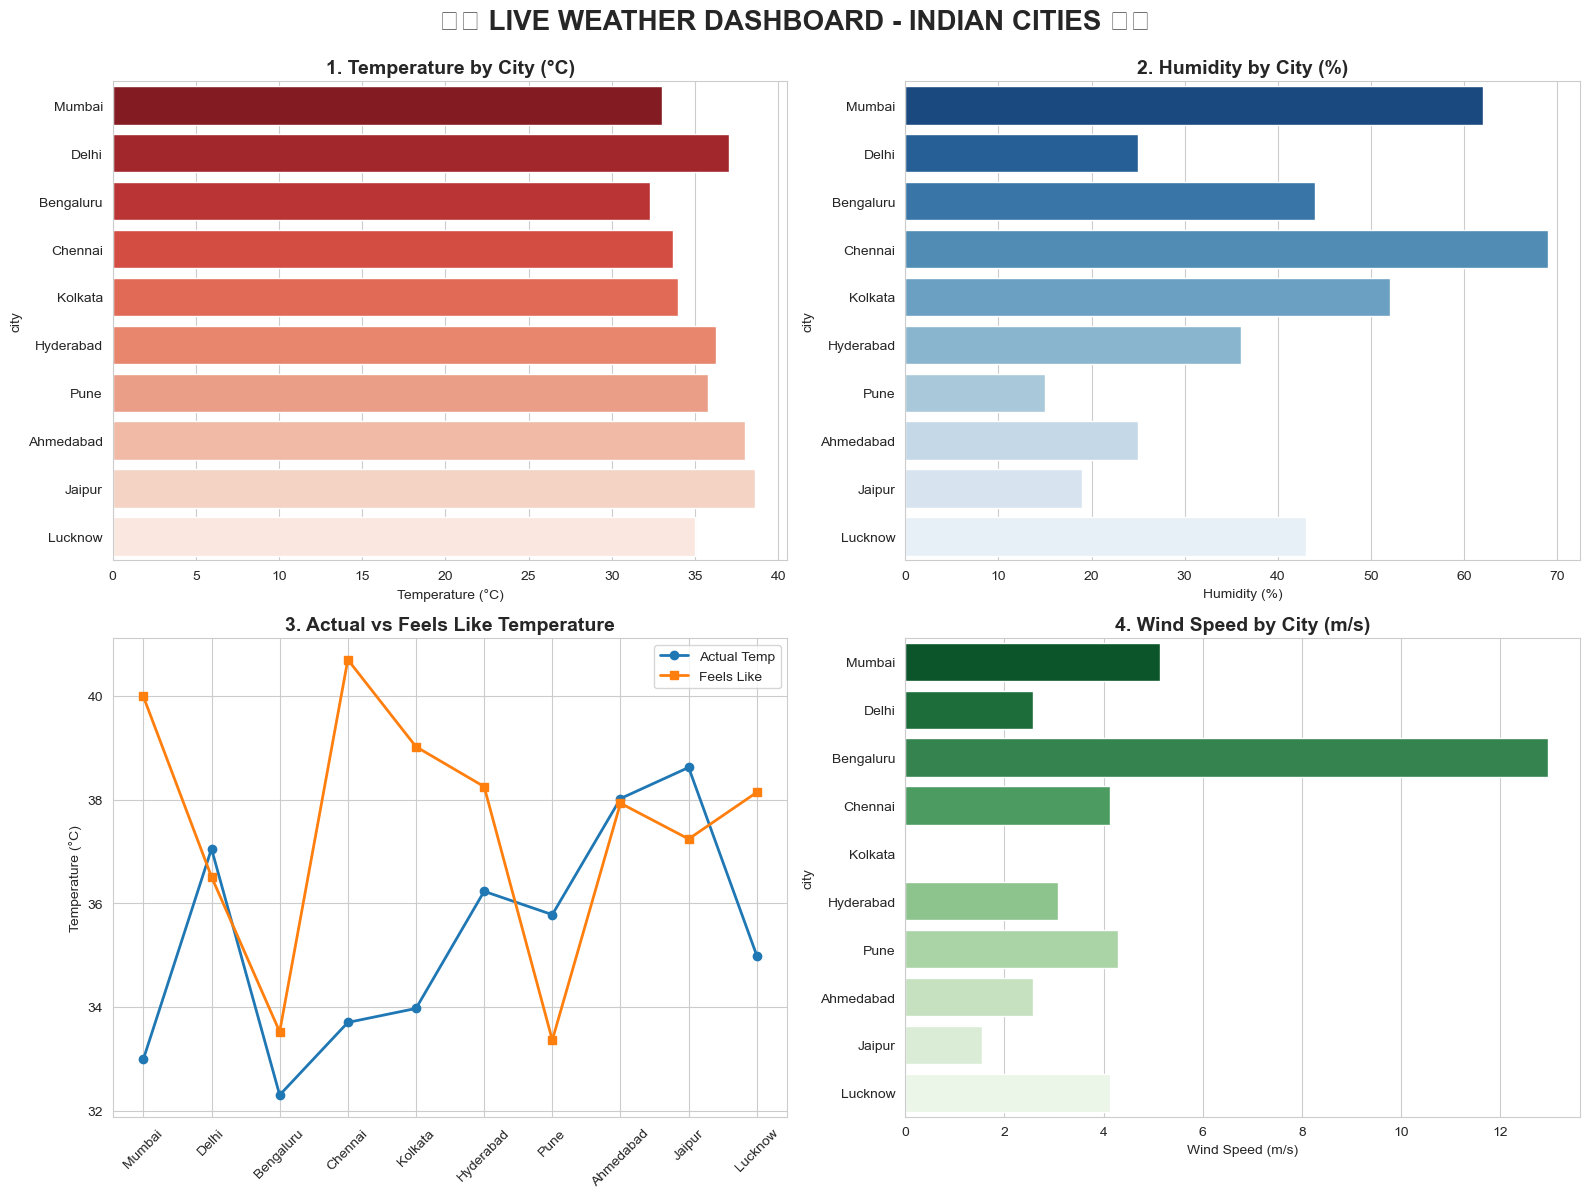

In [36]:
# Create weather dashboard

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_style('whitegrid')

# Chart 1: Temperature by City
sns.barplot(data=df, x='temperature', y='city', palette='Reds_r', ax=axes[0, 0])
axes[0, 0].set_title('1. Temperature by City (°C)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Temperature (°C)')

# Chart 2: Humidity by City
sns.barplot(data=df, x='humidity', y='city', palette='Blues_r', ax=axes[0, 1])
axes[0, 1].set_title('2. Humidity by City (%)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Humidity (%)')

# Chart 3: Feels Like vs Actual Temperature
x = range(len(df))
axes[1, 0].plot(x, df['temperature'], marker='o', label='Actual Temp', linewidth=2)
axes[1, 0].plot(x, df['feels_like'], marker='s', label='Feels Like', linewidth=2)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(df['city'], rotation=45)
axes[1, 0].set_title('3. Actual vs Feels Like Temperature', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Temperature (°C)')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Chart 4: Wind Speed
sns.barplot(data=df, x='wind_speed', y='city', palette='Greens_r', ax=axes[1, 1])
axes[1, 1].set_title('4. Wind Speed by City (m/s)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Wind Speed (m/s)')

fig.suptitle('🌤️ LIVE WEATHER DASHBOARD - INDIAN CITIES 🇮🇳', 
             fontsize=20, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

In [37]:
# Generate random user profiles (useful for testing apps)

url = 'https://randomuser.me/api/?results=10&nat=in'  # 10 Indian users

response= requests.get(url)
data= response.json()

users=[]

for user in data['results']:
    users.append({
        'name': f"{user['name']['first']} {user['name']['last']}",
        'gender': user['gender'],
        'email': user['email'],
        'city': user['location']['city'],
        'age': user['dob']['age']
    })

df=pd.DataFrame(users)
print(df)

                 name  gender                           email          city  \
0       Harish Moolya    male       harish.moolya@example.com      Tiruppur   
1       Niva Kulkarni  female       niva.kulkarni@example.com     Begusarai   
2  Rebecca Chiplunkar  female  rebecca.chiplunkar@example.com        Jaipur   
3     Reshma Bhardwaj  female     reshma.bhardwaj@example.com         Morbi   
4      Hiya Prajapati  female      hiya.prajapati@example.com      Bareilly   
5        Naksh Bansal    male        naksh.bansal@example.com       Nellore   
6    Rushali Bhardwaj  female    rushali.bhardwaj@example.com    Hazaribagh   
7    Trupti Prajapati  female    trupti.prajapati@example.com  Shahjahanpur   
8         Sarita Jain  female         sarita.jain@example.com       Katihar   
9     Advaith Chavare    male     advaith.chavare@example.com        Bokaro   

   age  
0   33  
1   48  
2   62  
3   34  
4   34  
5   61  
6   60  
7   32  
8   25  
9   40  


💰 LIVE CRYPTOCURRENCY PRICES:
   Cryptocurrency  Price in USD
0   Bitcoin (BTC)      79667.02
1  Ethereum (ETH)       2262.21


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4764\1648718654.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_crypto, x='Price in USD', y='Cryptocurrency', palette='viridis')


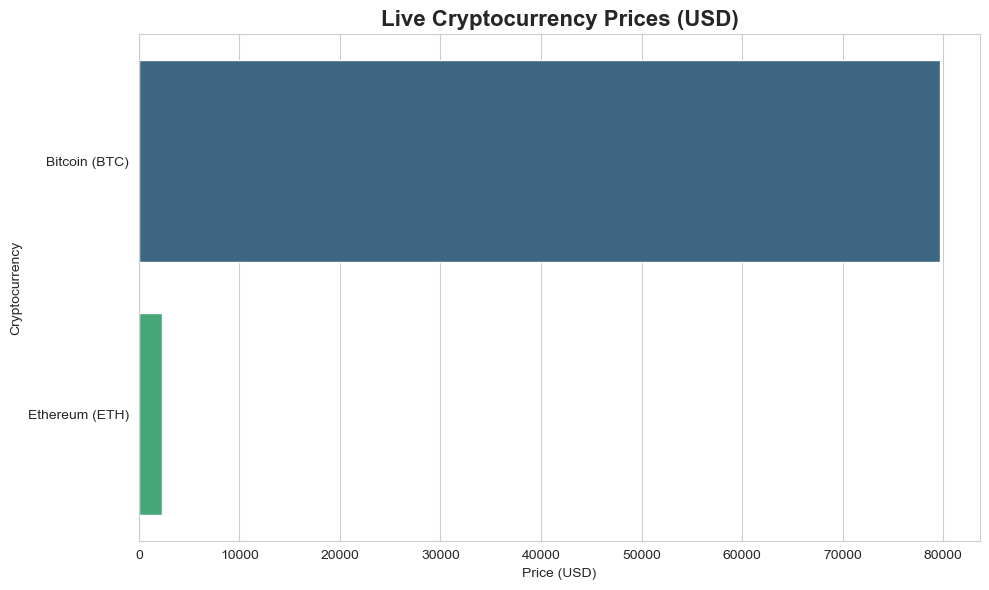

In [20]:
# Get live crypto prices

url = 'https://api.coinbase.com/v2/exchange-rates?currency=USD'

response = requests.get(url)
data = response.json()

# Get popular coins
crypto_prices = {
    'Bitcoin (BTC)': float(data['data']['rates']['BTC']),
    'Ethereum (ETH)': float(data['data']['rates']['ETH']),
}

# Convert to DataFrame
df_crypto = pd.DataFrame(list(crypto_prices.items()), columns=['Cryptocurrency', 'Price in USD'])
df_crypto['Price in USD'] = 1 / df_crypto['Price in USD']  # Invert rates

print("💰 LIVE CRYPTOCURRENCY PRICES:")
print(df_crypto)

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=df_crypto, x='Price in USD', y='Cryptocurrency', palette='viridis')
plt.title('Live Cryptocurrency Prices (USD)', fontsize=16, fontweight='bold')
plt.xlabel('Price (USD)')
plt.tight_layout()
plt.show()